In [1]:
!pip install -q tensorflow scikit-learn seaborn pillow kagglehub


In [2]:
import os
import glob as _glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

np.random.seed(42)

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", dataset_path)

DATA_DIR = dataset_path


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000


In [4]:
metadata_path = _glob.glob(os.path.join(DATA_DIR, '**', 'HAM10000_metadata.csv'), recursive=True)[0]
print("Metadata CSV:", metadata_path)


Metadata CSV: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [5]:
skin_df = pd.read_csv(metadata_path)

SIZE = 32  # image resize dimension

le = LabelEncoder()
le.fit(skin_df['dx'])
print(list(le.classes_))

skin_df['label'] = le.transform(skin_df["dx"])
skin_df.sample(10)


['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
9854,HAM_0002441,ISIC_0031381,akiec,histo,80.0,male,scalp,0
7665,HAM_0003966,ISIC_0032644,nv,histo,35.0,female,foot,5
9571,HAM_0004199,ISIC_0033556,nv,consensus,40.0,female,unknown,5
416,HAM_0001325,ISIC_0030522,bkl,histo,70.0,male,scalp,2
7277,HAM_0001220,ISIC_0029636,nv,histo,60.0,female,chest,5
2650,HAM_0003072,ISIC_0033499,bcc,histo,85.0,male,face,1
7926,HAM_0002915,ISIC_0034097,nv,histo,65.0,male,upper extremity,5
5018,HAM_0001898,ISIC_0026917,nv,follow_up,50.0,female,abdomen,5
7736,HAM_0006567,ISIC_0033439,nv,histo,30.0,female,back,5
1393,HAM_0004676,ISIC_0026247,mel,histo,85.0,male,back,4


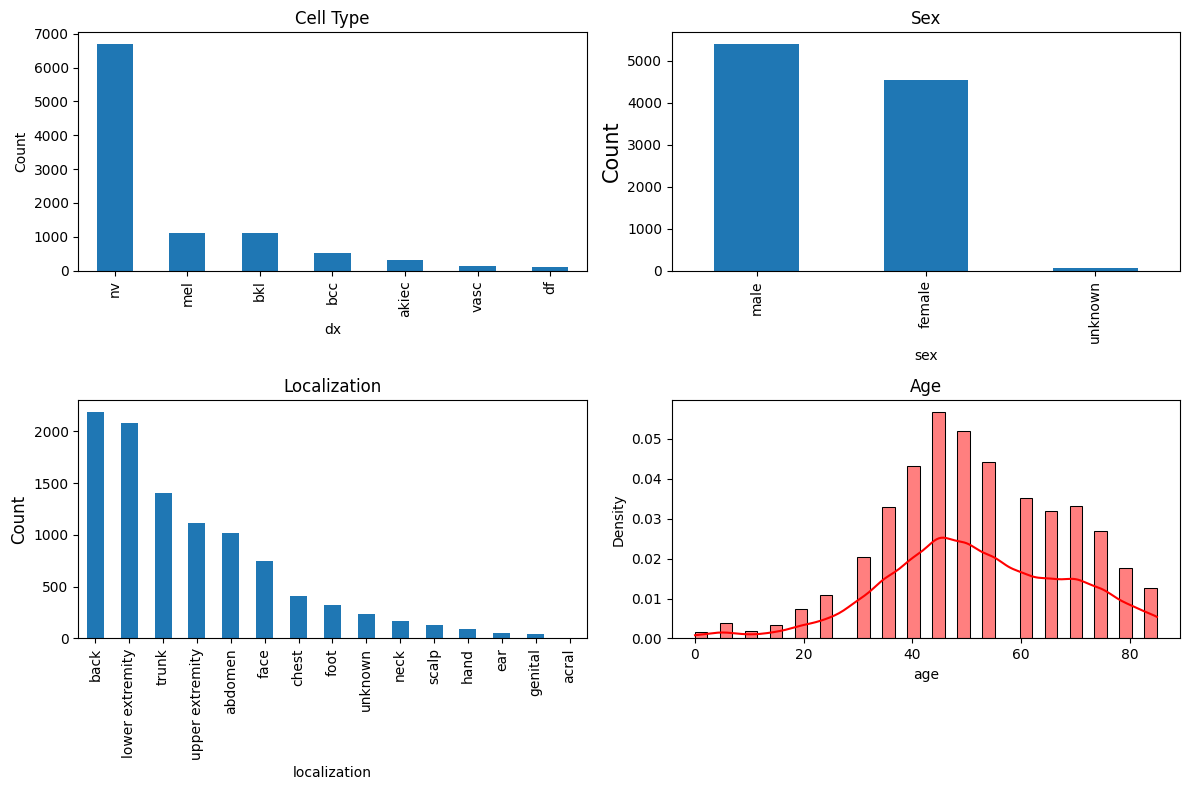

In [6]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Type')

ax2 = fig.add_subplot(222)
skin_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count', size=15)
ax2.set_title('Sex')

ax3 = fig.add_subplot(223)
skin_df['localization'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count', size=12)
ax3.set_title('Localization')

ax4 = fig.add_subplot(224)
sample_age = skin_df[pd.notnull(skin_df['age'])]
sns.histplot(sample_age['age'], kde=True, stat='density', color='red', ax=ax4)
ax4.set_title('Age')

plt.tight_layout()
plt.show()


In [7]:
print(skin_df['label'].value_counts())

df_0 = skin_df[skin_df['label'] == 0]
df_1 = skin_df[skin_df['label'] == 1]
df_2 = skin_df[skin_df['label'] == 2]
df_3 = skin_df[skin_df['label'] == 3]
df_4 = skin_df[skin_df['label'] == 4]
df_5 = skin_df[skin_df['label'] == 5]
df_6 = skin_df[skin_df['label'] == 6]

n_samples = 500
df_0_balanced = resample(df_0, replace=True, n_samples=n_samples, random_state=42)
df_1_balanced = resample(df_1, replace=True, n_samples=n_samples, random_state=42)
df_2_balanced = resample(df_2, replace=True, n_samples=n_samples, random_state=42)
df_3_balanced = resample(df_3, replace=True, n_samples=n_samples, random_state=42)
df_4_balanced = resample(df_4, replace=True, n_samples=n_samples, random_state=42)
df_5_balanced = resample(df_5, replace=True, n_samples=n_samples, random_state=42)
df_6_balanced = resample(df_6, replace=True, n_samples=n_samples, random_state=42)

skin_df_balanced = pd.concat([
    df_0_balanced, df_1_balanced, df_2_balanced,
    df_3_balanced, df_4_balanced, df_5_balanced, df_6_balanced
])

print(skin_df_balanced['label'].value_counts())


label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64
label
0    500
1    500
2    500
3    500
4    500
5    500
6    500
Name: count, dtype: int64


In [8]:
# Map image_id -> file path across all image subfolders in the dataset
image_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in _glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)
}

skin_df_balanced['path'] = skin_df_balanced['image_id'].map(image_path.get)
skin_df_balanced['image'] = skin_df_balanced['path'].map(
    lambda x: np.asarray(Image.open(x).resize((SIZE, SIZE)))
)


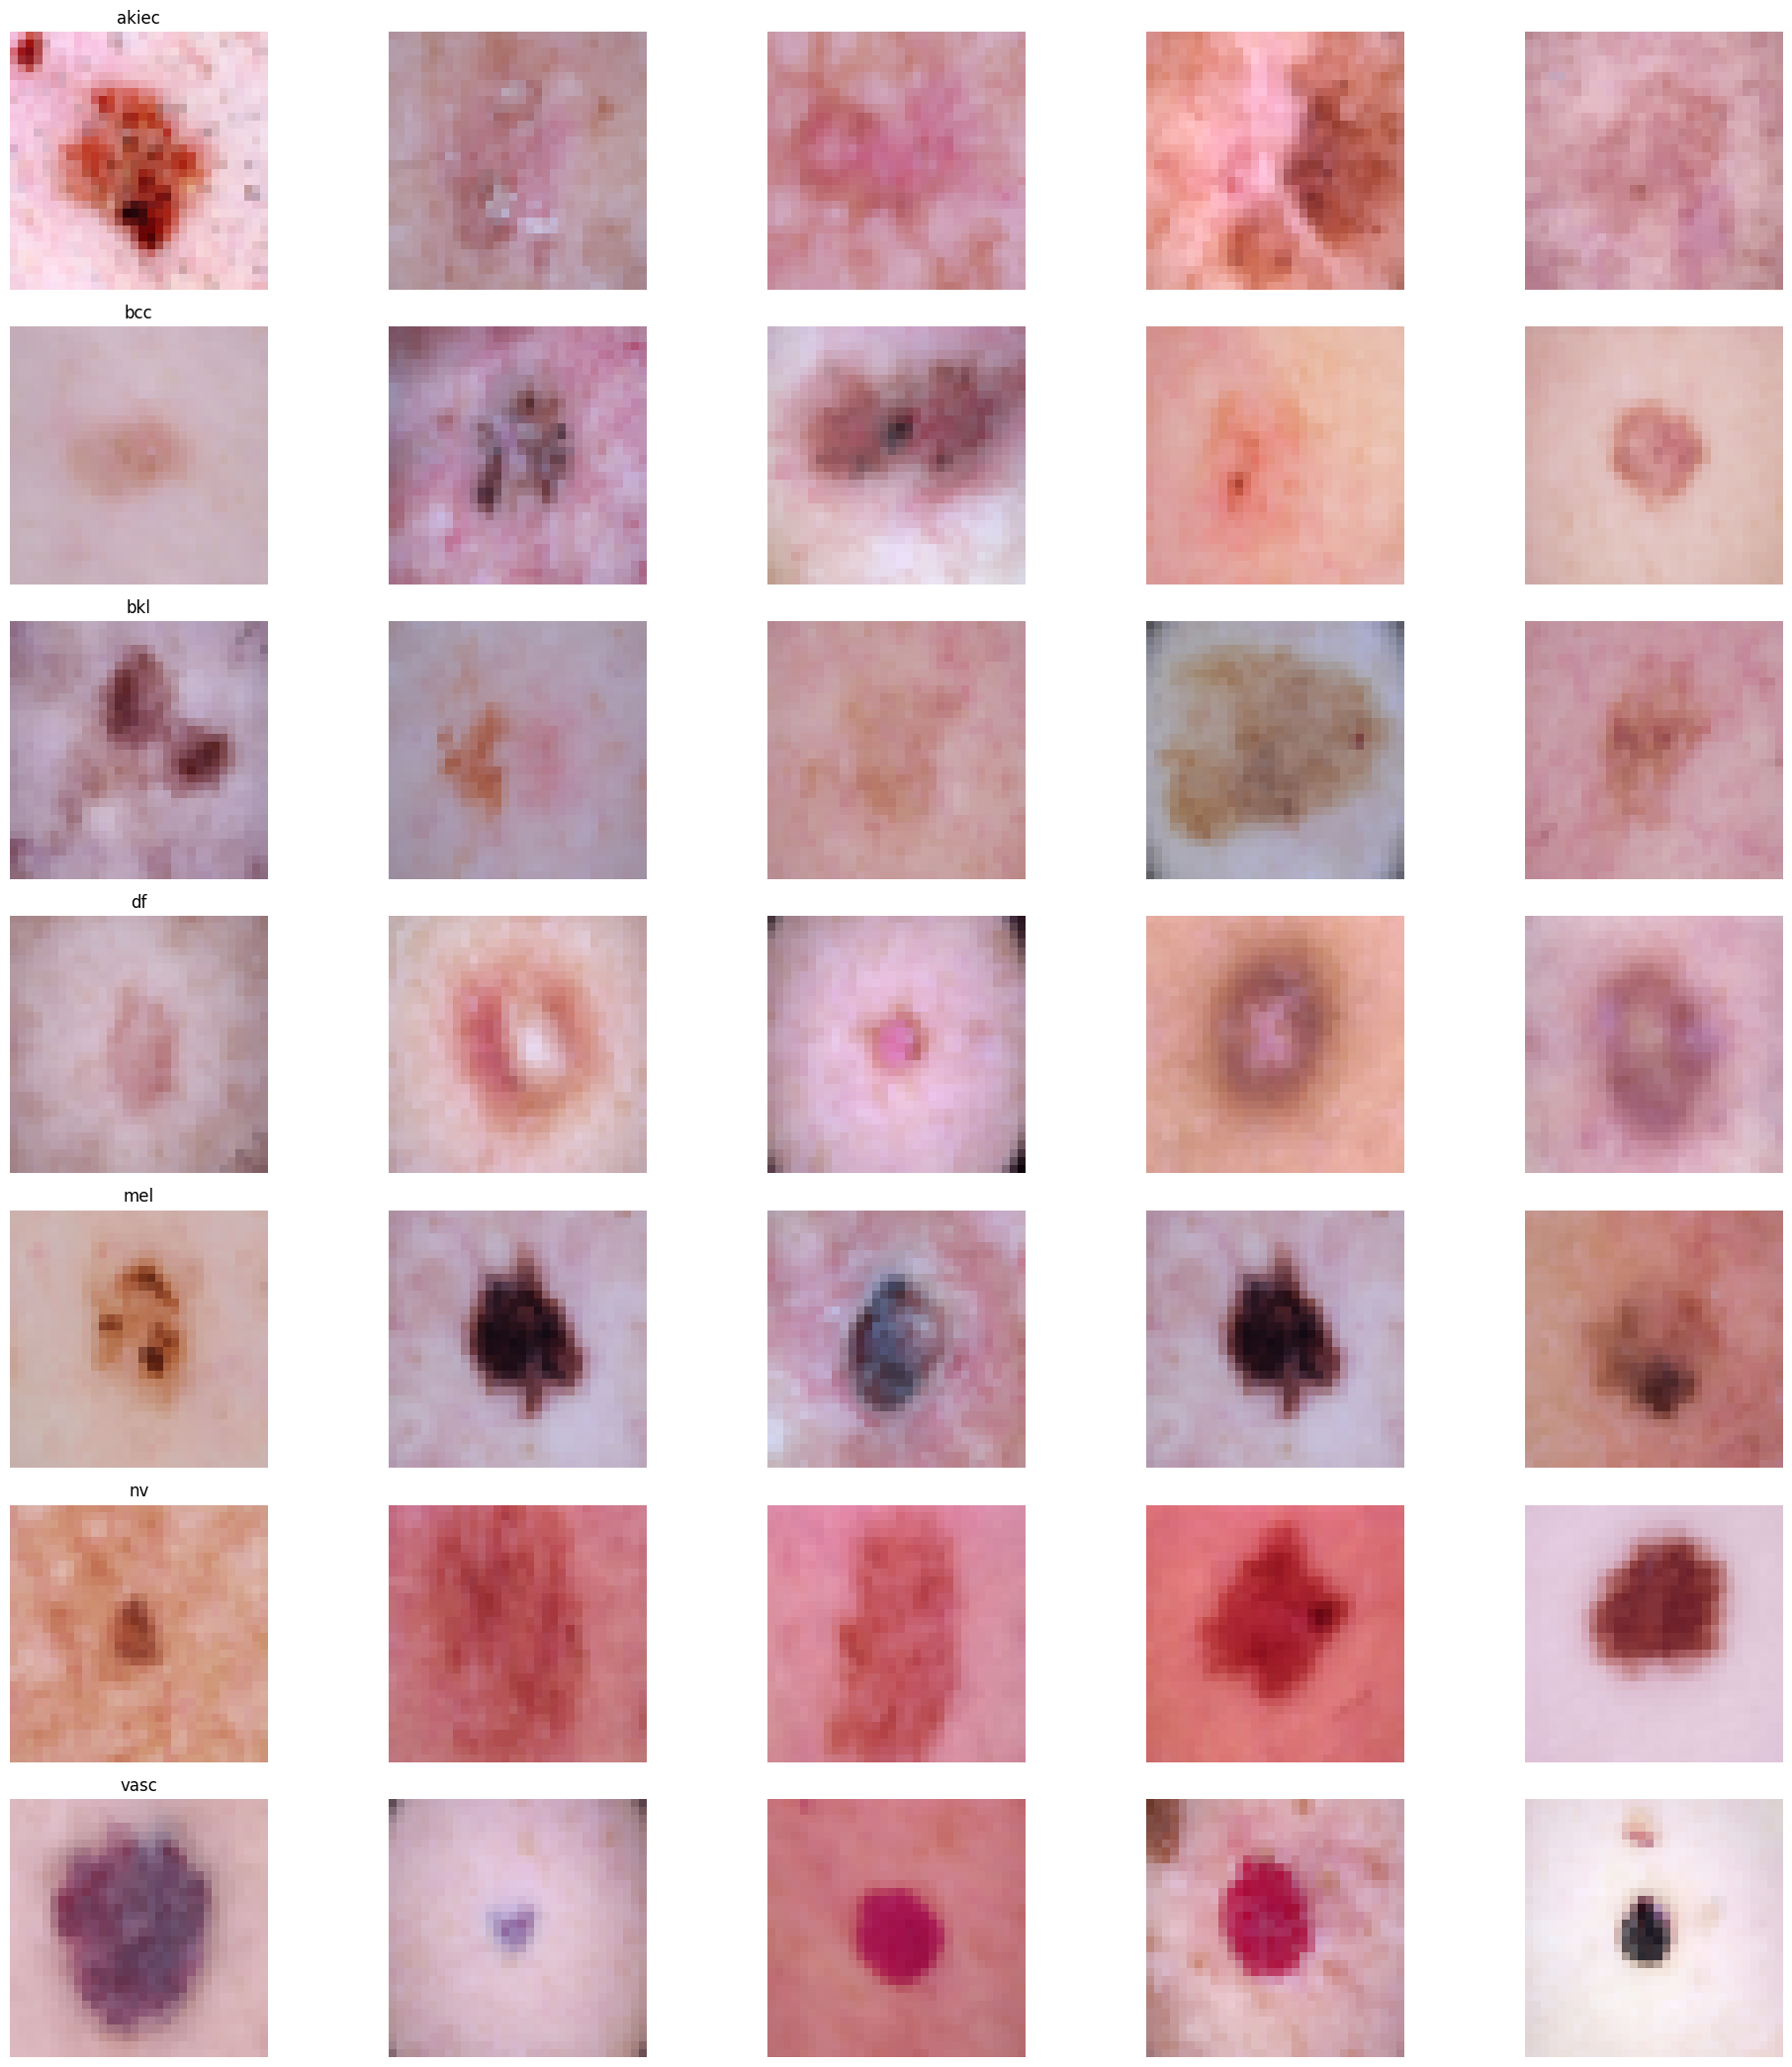

In [9]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize=(4 * n_samples, 3 * 7))
for n_axs, (type_name, type_rows) in zip(m_axs, skin_df_balanced.sort_values(['dx']).groupby('dx')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
plt.tight_layout()
plt.show()


In [10]:
X = np.asarray(skin_df_balanced['image'].tolist())
X = X / 255.  # scale pixel values to 0-1

Y = skin_df_balanced['label']
Y_cat = to_categorical(Y, num_classes=7)

x_train, x_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.25, random_state=42)
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


Train shape: (2625, 32, 32, 3) Test shape: (875, 32, 32, 3)


In [11]:
num_classes = 7

model = Sequential()
model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(SIZE, SIZE, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.3))
model.add(Flatten())

model.add(Dense(32))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,455 (1.47 MB)

 Trainable params: 384,455 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
batch_size = 16
epochs = 50

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test),
    verbose=2
)

score = model.evaluate(x_test, y_test)
print('Test accuracy:', score[1])


Epoch 1/50
165/165 - 42s - 257ms/step - acc: 0.2038 - loss: 1.8900 - val_acc: 0.2686 - val_loss: 1.7977
Epoch 2/50
165/165 - 36s - 218ms/step - acc: 0.2701 - loss: 1.7486 - val_acc: 0.3166 - val_loss: 1.8335
Epoch 3/50
165/165 - 40s - 243ms/step - acc: 0.3516 - loss: 1.5959 - val_acc: 0.3497 - val_loss: 1.5425
Epoch 4/50
165/165 - 40s - 245ms/step - acc: 0.4046 - loss: 1.4750 - val_acc: 0.3863 - val_loss: 1.4375
Epoch 5/50
165/165 - 32s - 194ms/step - acc: 0.4122 - loss: 1.4332 - val_acc: 0.4240 - val_loss: 1.4209
Epoch 6/50
165/165 - 41s - 250ms/step - acc: 0.4564 - loss: 1.3766 - val_acc: 0.4674 - val_loss: 1.3267
Epoch 7/50
165/165 - 41s - 246ms/step - acc: 0.4648 - loss: 1.3470 - val_acc: 0.4514 - val_loss: 1.3473
Epoch 8/50
165/165 - 42s - 253ms/step - acc: 0.4789 - loss: 1.3057 - val_acc: 0.4880 - val_loss: 1.2735
Epoch 9/50
165/165 - 43s - 259ms/step - acc: 0.4930 - loss: 1.2709 - val_acc: 0.4926 - val_loss: 1.2611
Epoch 10/50
165/165 - 32s - 192ms/step - acc: 0.5101 - loss: 1.2

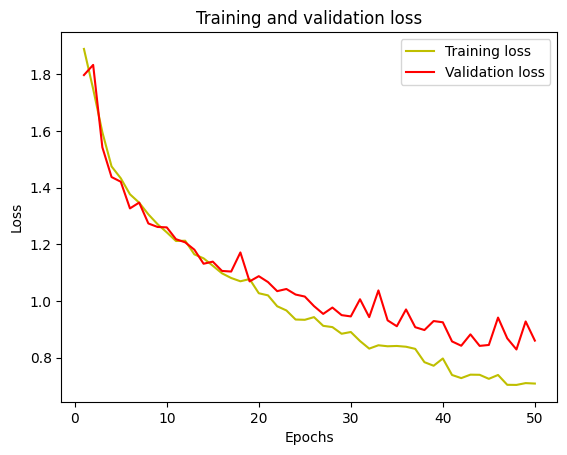

In [13]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.plot(epochs_range, loss, 'y', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


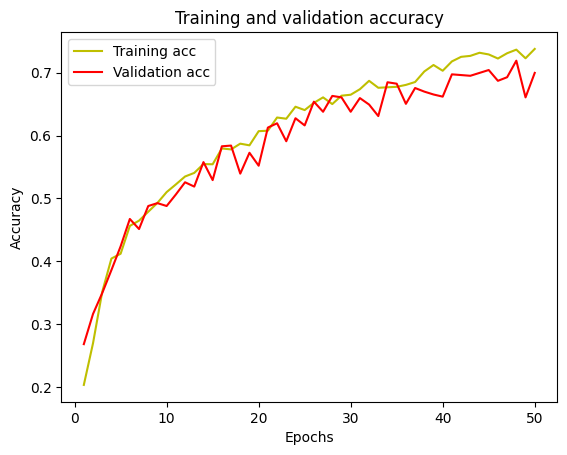

In [14]:
acc = history.history['acc']
val_acc = history.history['val_acc']

plt.plot(epochs_range, acc, 'y', label='Training acc')
plt.plot(epochs_range, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step


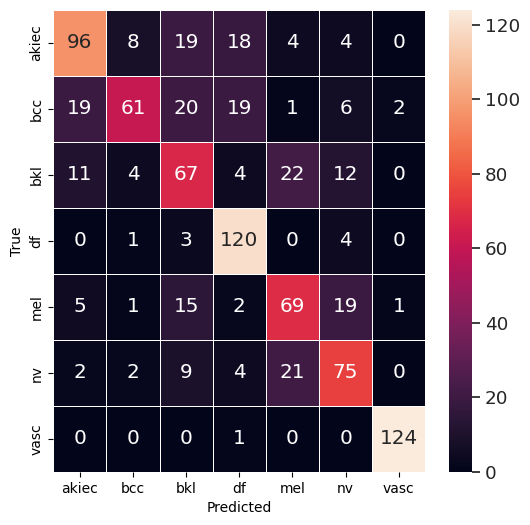

In [15]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(6, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', linewidths=.5, ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.show()


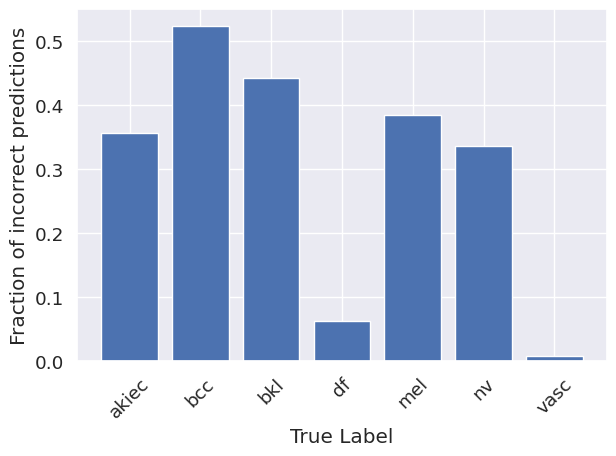

In [16]:
# Fraction of incorrect predictions per true class
incorr_fraction = 1 - np.diag(cm) / np.sum(cm, axis=1)
plt.bar(np.arange(7), incorr_fraction, tick_label=le.classes_)
plt.xticks(rotation=45)
plt.xlabel('True Label')
plt.ylabel('Fraction of incorrect predictions')
plt.tight_layout()
plt.show()
